# 2.1 Bagging

這份筆記沿用原本的教學脈絡，示範如何在 `iris` 資料集上使用 **Bagging (Bootstrap Aggregating)**，
並比較不同 base model 套上 Bagging 前後的表現。

本 notebook 以 **scikit-learn 現代寫法** 為主，盡量保持內容精簡，不額外離題。

現代實務通常幾乎會直接用 **`RandomForestClassifier`**，Bagging 比較偏「教學與基礎概念」。  
Random Forest = Bagging + feature 隨機化，除了降 variance 也降低 correlation

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets, tree, svm
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB

## 1. 載入資料

這裡沿用經典的 `iris` 資料集。

- `X`：特徵矩陣（150 筆資料 × 4 個特徵）
- `y`：分類標籤（3 個品種）

In [12]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

print('X shape:', X.shape)
print('y shape:', y.shape)
print('feature names:', iris.feature_names)
print('target names:', iris.target_names)

X shape: (150, 4)
y shape: (150,)
feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target names: ['setosa' 'versicolor' 'virginica']


## 2. 切分訓練集與測試集

使用 `stratify=y`，讓訓練集與測試集中的類別比例維持一致。

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=0,
    stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('len(X_test)   :', len(X_test))

X_train shape: (105, 4)
X_test shape : (45, 4)
len(X_test)   : 45


## 3. Bagging 的概念

Bagging 的全名是 **Bootstrap Aggregating**。

它的做法是：
1. 對訓練資料做多次 **有放回抽樣**（bootstrap sampling）
2. 每次抽樣都訓練一個 base model
3. 最後把多個模型的結果做整合（分類通常是多數決）

### Bagging 主要想改善什麼？

Bagging 主要用來 **降低 variance**，所以通常對像 Decision Tree 這種較不穩定的模型幫助會比較明顯。

如果 base model 本身 variance 不高，或資料量不足，Bagging 可能會增加 bias，導致整體表現下降。

### 為什麼也示範 `GaussianNB()`？

這裡保留原本教學脈絡中的 `GaussianNB()`，是為了當作對照。
`GaussianNB` 假設每個特徵在各類別中近似常態分布，模型偏簡單、假設也比較強，
因此 Bagging 對它的提升通常不會像 Decision Tree 那麼明顯。

這樣可以幫助觀察：**不是所有模型套上 Bagging 都會有同樣程度的改善。**

## 4. 準備 base model

先保留原本 notebook 的三種候選模型：

- `DecisionTreeClassifier()`
- `LinearSVC()`
- `GaussianNB()`

預設先示範 `DecisionTreeClassifier()`，因為它通常比較能看出 Bagging 的效果。

In [14]:
# 三種可切換的 base model
# base_clf = svm.LinearSVC(dual='auto', random_state=0)
# base_clf = GaussianNB()
base_clf = tree.DecisionTreeClassifier(random_state=0)

base_clf

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

## 5. 建立 BaggingClassifier

這裡仍然貼近原本的參數設計，但補上較清楚的寫法：

- `n_estimators=10`：建立 10 個 base model  
    10（教學） → 100~500（實務）
- `bootstrap=True`：對樣本做有放回抽樣
- `bootstrap_features=False`：對特徵不做放回抽樣  
    sklearn 預設 False 是忠實 Bagging 的原始核心  
    bootstrap samples（對資料抽樣）+ 同一組 features  
    讓每個模型看到不同「資料」，而不是不同「特徵」
    適合設定為 True 的情境：  
    feature 很多（高維資料）  
    feature 有 redundancy  
    想增加模型多樣性  
- `max_samples=0.7`：每個 base model 使用 70% 的樣本
- `max_features=3`：每個 base model 使用 3 個特徵

這個設定偏向教學示範，因此刻意讓不同 base model 看到的資料與特徵都不完全相同。

In [15]:
bagging = BaggingClassifier(
    estimator=base_clf,
    n_estimators=10,
    bootstrap=True,
    bootstrap_features=False,
    max_features=3,
    max_samples=0.7,
    random_state=0
)

bagging

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...andom_state=0)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",10
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.7
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",3
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",0
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


## 6. 先比較 base model 與 Bagging model

和原 notebook 相比，這裡多補一個 **baseline 比較**。
這樣比較容易看出套上 Bagging 是否真的帶來幫助。

In [16]:
base_clf.fit(X_train, y_train)
bagging.fit(X_train, y_train)

base_train_acc = base_clf.score(X_train, y_train)
base_test_acc = base_clf.score(X_test, y_test)
bag_train_acc = bagging.score(X_train, y_train)
bag_test_acc = bagging.score(X_test, y_test)

result_df = pd.DataFrame({
    'model': ['Base model', 'Bagging'],
    'train_accuracy': [base_train_acc, bag_train_acc],
    'test_accuracy': [base_test_acc, bag_test_acc],
})

result_df

,model,train_accuracy,test_accuracy
0,Base model,1.000000,0.977778
1,Bagging,0.980952,0.977778


## 7. 預測結果

延續原本的操作，先看 `BaggingClassifier` 對測試集的預測。

In [17]:
y_pred = bagging.predict(X_test)
y_pred[:10]

array([2, 2, 0, 0, 1, 0, 1, 2, 0, 1])

## 8. `X[:, 2]`、`X[:, 3]` 到底是什麼？

這是 numpy 的二維索引方式：

```python
X[列, 欄]
```

所以：

- `X[:, 2]`：取 **所有列** 的 **第 3 欄特徵**
- `X[:, 3]`：取 **所有列** 的 **第 4 欄特徵**

這裡的 `:` 表示「全部 row」。

以 `iris` 來說：

- `X[:, 2]` = petal length（花瓣長度）
- `X[:, 3]` = petal width（花瓣寬度）

也就是說，下面的散點圖會拿：

- x 軸：第 3 個特徵
- y 軸：第 4 個特徵

In [18]:
print('X[:, 2].shape:', X[:, 2].shape)
print('X[:, 3].shape:', X[:, 3].shape)
print('前 5 筆 X[:, 2] :', X[:5, 2])
print('前 5 筆 X[:, 3] :', X[:5, 3])

X[:, 2].shape: (150,)
X[:, 3].shape: (150,)
前 5 筆 X[:, 2] : [1.4 1.4 1.3 1.5 1.4]
前 5 筆 X[:, 3] : [0.2 0.2 0.2 0.2 0.2]


## 9. 視覺化：真實標籤 vs Bagging 預測

保留原本的視覺化方式，但補上標題與座標名稱，讓圖更容易閱讀。

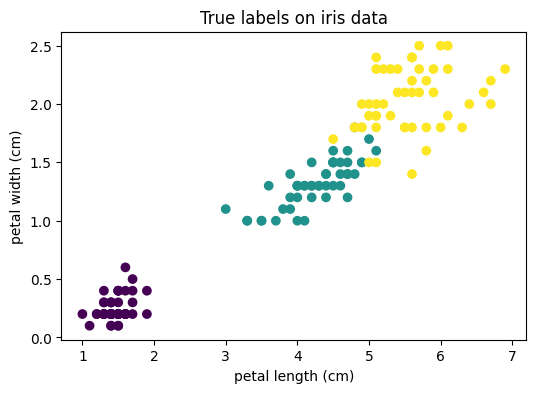

In [19]:
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 2], X[:, 3], c=y)
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.title('True labels on iris data')
plt.show()

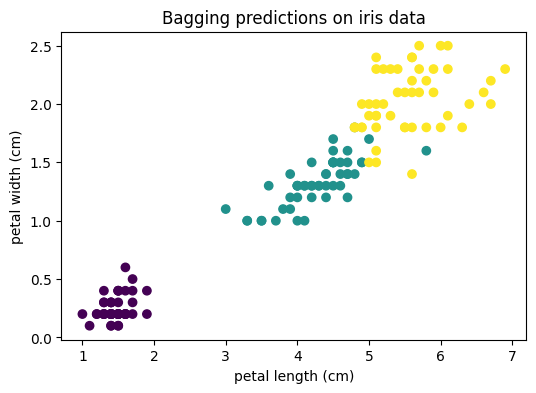

In [20]:
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 2], X[:, 3], c=bagging.predict(X))
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.title('Bagging predictions on iris data')
plt.show()

## 10. 小結

這份 notebook 保留了原本的教學主線：

1. 載入 `iris` 資料
2. 切分訓練集 / 測試集
3. 選一個 base model
4. 套用 `BaggingClassifier`
5. 比較結果並做簡單視覺化

如果你接下來想延伸，最自然的下一步會是：

- 只切換 `base_clf`，比較 `DecisionTree`、`LinearSVC`、`GaussianNB` 套上 Bagging 前後差異
- 觀察哪些模型更適合用 Bagging
- 進一步理解 bias / variance 的差別

Bagging reduces variance by averaging multiple models.

Bagging is most effective for high-variance models such as decision trees.
For low-variance, high-bias models, its benefit is limited and may even hurt performance.

bootstrap_features=True introduces feature-level randomness at the model level,
but unlike Random Forest, which applies randomness at each split,
Bagging only samples features once per estimator.

Random Forest further improves Bagging by reducing correlation between trees
through random feature selection.

Feature sampling in Bagging is optional and applied at the estimator level,
while Random Forest performs feature sampling at each split,
making it more effective at reducing correlation between trees.

Neither Bagging nor Random Forest primarily reduces bias.  

Random Forest increases bias at the individual tree level due to feature randomness,
but aggregation compensates for it, resulting in similar overall bias while significantly reducing variance.